# Chapter 1 - Common Conventions and API Elements

## Summary

Chapter ini memperkenalkan struktur dasar Scikit-Learn dan API yang digunakan hampir di seluruh library. Konsep utama yang dibahas adalah Estimator, Transformer, dan Pipeline. Memahami ketiga konsep ini sangat penting karena menjadi fondasi seluruh workflow Machine Learning menggunakan Scikit-Learn.

## Theoretical Explanation

### Estimator

Estimator adalah objek yang dapat mempelajari pola dari data menggunakan method fit().

Contoh estimator:

- LinearRegression
- LogisticRegression
- RandomForestClassifier
- SVC

Workflow:

Data → fit() → Trained Model

### Transformer

Transformer digunakan untuk mengubah data menjadi bentuk lain menggunakan method transform().

Contoh:

- StandardScaler
- MinMaxScaler
- PCA
- OneHotEncoder

Workflow:

Data → fit() → transform()

atau

Data → fit_transform()

### Predictor

Predictor adalah estimator yang dapat menghasilkan prediksi menggunakan method predict().

Workflow:

fit() → predict()

### Pipeline

Pipeline digunakan untuk menggabungkan preprocessing dan model menjadi satu workflow yang konsisten.

Contoh:

Data → Scaling → Classification

### Benefits of Scikit-Learn API

- Konsisten
- Mudah dipelajari
- Modular
- Dapat dikombinasikan dengan Pipeline

---

## Code Reproduction

In [1]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [2]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [3]:
predictions = model.predict(X[:5])

print(predictions)

[206.11667725  68.07103297 176.88279035 166.91445843 128.46225834]


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.80050009  1.06548848  1.29708846  0.45984057 -0.92974581 -0.73206462
  -0.91245053 -0.05449919  0.41853093 -0.37098854]
 [-0.03956713 -0.93853666 -1.08218016 -0.55350458 -0.17762425 -0.40288615
   1.56441355 -0.83030083 -1.43658851 -1.93847913]
 [ 1.79330681  1.06548848  0.93453324 -0.1192138  -0.95867356 -0.71889748
  -0.68024452 -0.05449919  0.06015558 -0.54515416]
 [-1.87244107 -0.93853666 -0.24377122 -0.77064997  0.25629203  0.52539714
  -0.75764652  0.72130245  0.47698252 -0.19682291]
 [ 0.11317236 -0.93853666 -0.76494435  0.45984057  0.08272552  0.32789006
   0.17117751 -0.05449919 -0.67250161 -0.98056821]]


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(X, y)

print("Pipeline created successfully")

Pipeline created successfully


In [6]:
pred = pipe.predict(X[:5])

print(pred)

[206.11667725  68.07103297 176.88279035 166.91445843 128.46225834]


## Conclusion

Chapter ini memperkenalkan fondasi penggunaan Scikit-Learn yaitu Estimator, Transformer, dan Pipeline. Ketiga komponen ini menjadi dasar hampir seluruh implementasi Machine Learning menggunakan Scikit-Learn.

# Chapter 2 - Pre-Model Workflow and Data Preprocessing

## Summary

Chapter ini membahas berbagai teknik preprocessing data yang perlu dilakukan sebelum melatih model Machine Learning. Proses preprocessing sangat penting karena kualitas data secara langsung memengaruhi performa model.

## Theoretical Explanation

### Data Preprocessing

Data preprocessing adalah proses membersihkan dan mempersiapkan data sebelum digunakan oleh model Machine Learning.

Tahapan umum:

- Missing Value Handling
- Encoding
- Feature Scaling
- Feature Selection

### Missing Values

Missing values adalah data yang hilang atau kosong.

Beberapa teknik penanganan:

- Mean Imputation
- Median Imputation
- Most Frequent Imputation

### Standardization

Standardization mengubah data agar memiliki:

Mean = 0

Standard Deviation = 1

### Normalization

Normalization mengubah data ke rentang tertentu, biasanya:

0 → 1

### Categorical Encoding

Karena model tidak memahami teks, data kategorikal harus diubah menjadi numerik.

Contoh:

Jakarta → [1,0,0]

Bandung → [0,1,0]

Surabaya → [0,0,1]

### One-Hot Encoding

Metode paling umum untuk mengubah data kategorikal menjadi numerik.

---

## Code Reproduction

In [7]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    "Age":[21,25,np.nan,30,29],
    "Salary":[5000,np.nan,7000,9000,8500]
})

data

,Age,Salary
0,21.0,5000.0
1,25.0,NaN
2,NaN,7000.0
3,30.0,9000.0
4,29.0,8500.0


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="mean"
)

data_imputed = imputer.fit_transform(data)

print(data_imputed)

[[  21.   5000.  ]
 [  25.   7375.  ]
 [  26.25 7000.  ]
 [  30.   9000.  ]
 [  29.   8500.  ]]


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    data_imputed
)

print(scaled_data)

[[-1.64788265 -1.70625037]
 [-0.39235301  0.        ]
 [ 0.         -0.26940795]
 [ 1.17705904  1.16743446]
 [ 0.86317663  0.80822386]]


In [10]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

normalized_data = minmax.fit_transform(
    data_imputed
)

print(normalized_data)

[[0.         0.        ]
 [0.44444444 0.59375   ]
 [0.58333333 0.5       ]
 [1.         1.        ]
 [0.88888889 0.875     ]]


In [11]:
cities = pd.DataFrame({
    "City":[
        "Jakarta",
        "Bandung",
        "Surabaya",
        "Jakarta"
    ]
})

cities

,City
0,Jakarta
1,Bandung
2,Surabaya
3,Jakarta


In [12]:
encoded = pd.get_dummies(
    cities,
    columns=["City"]
)

encoded

,City_Bandung,City_Jakarta,City_Surabaya
0,False,True,False
1,True,False,False
2,False,False,True
3,False,True,False


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

data = pd.DataFrame({
    "City":["Jakarta","Bandung","Surabaya"],
    "Age":[21,25,30]
})

preprocessor = ColumnTransformer([
    (
        "city",
        OneHotEncoder(),
        ["City"]
    )
],
remainder="passthrough")

processed = preprocessor.fit_transform(
    data
)

print(processed)

[[ 0.  1.  0. 21.]
 [ 1.  0.  0. 25.]
 [ 0.  0.  1. 30.]]


In [14]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler())
])

result = pipeline.fit_transform(
    data_imputed
)

print(result)

[[-1.64788265 -1.70625037]
 [-0.39235301  0.        ]
 [ 0.         -0.26940795]
 [ 1.17705904  1.16743446]
 [ 0.86317663  0.80822386]]


## Conclusion

Pada chapter ini dipelajari berbagai teknik preprocessing data yang digunakan sebelum proses pelatihan model. Missing value handling, scaling, normalization, dan encoding merupakan langkah penting untuk menghasilkan model Machine Learning yang lebih akurat dan stabil.

## Conclusion

Pada chapter ini dipelajari berbagai teknik preprocessing data yang digunakan sebelum proses pelatihan model. Missing value handling, scaling, normalization, dan encoding merupakan langkah penting untuk menghasilkan model Machine Learning yang lebih akurat dan stabil.

In [15]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)

(150, 4)


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(150, 2)


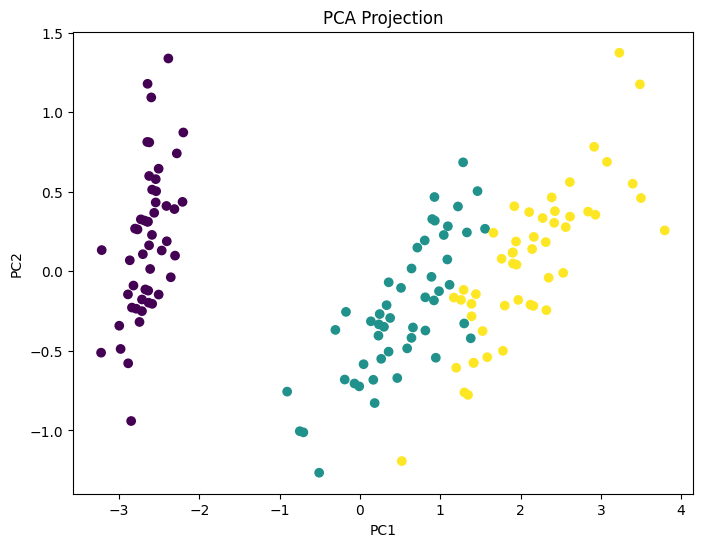

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [18]:
print(
    pca.explained_variance_ratio_
)

[0.92461872 0.05306648]


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X,
    y
)

print(X_lda.shape)

(150, 2)


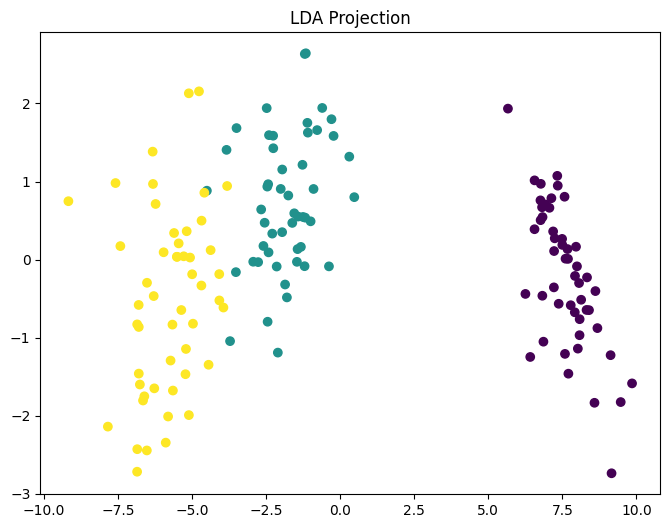

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y
)

plt.title("LDA Projection")

plt.show()

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

print(X_tsne.shape)

(150, 2)


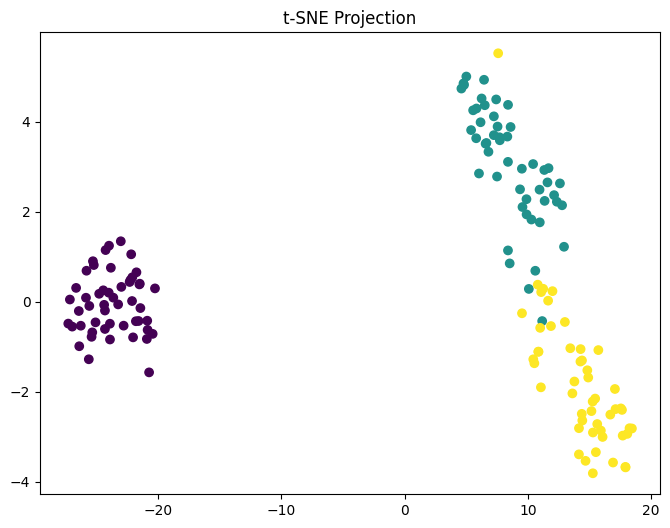

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y
)

plt.title("t-SNE Projection")

plt.show()

## Conclusion

Pada chapter ini dipelajari berbagai teknik reduksi dimensi seperti PCA, LDA, dan t-SNE. PCA dan LDA dapat digunakan untuk menyederhanakan dataset, sedangkan t-SNE sangat berguna untuk visualisasi data berdimensi tinggi.

# Chapter 4 - Nearest Neighbors Methods

## Summary

Chapter ini membahas algoritma K-Nearest Neighbors (KNN) dan berbagai konsep yang berkaitan dengan pengukuran jarak antar data. KNN merupakan salah satu algoritma Machine Learning yang paling sederhana namun efektif untuk klasifikasi dan regresi.

## Theoretical Explanation

### K-Nearest Neighbors (KNN)

KNN bekerja dengan mencari sejumlah tetangga terdekat dari sebuah data.

Langkah kerja:

1. Hitung jarak
2. Ambil k tetangga terdekat
3. Tentukan mayoritas kelas

### Euclidean Distance

Jarak garis lurus antara dua titik.

### Manhattan Distance

Jarak berdasarkan jumlah perbedaan absolut antar fitur.

### Choosing K

Nilai K mempengaruhi performa model:

- K kecil → sensitif terhadap noise
- K besar → lebih stabil

### Advantages

- Mudah dipahami
- Tidak membutuhkan training kompleks

### Disadvantages

- Lambat untuk dataset besar
- Sensitif terhadap skala data

---

## Code Reproduction

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=42
)

print(X_train.shape)

(426, 30)


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

print(
    "Accuracy:",
    knn.score(
        X_test,
        y_test
    )
)

Accuracy: 0.965034965034965


In [25]:
prediction = knn.predict(
    X_test[:5]
)

print(prediction)

[1 0 0 1 1]


In [26]:
for k in [1,3,5,7,9]:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    score = model.score(
        X_test,
        y_test
    )

    print(
        f"K={k}: {score:.4f}"
    )

K=1: 0.9301
K=3: 0.9301
K=5: 0.9650
K=7: 0.9580
K=9: 0.9580


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

knn_scaled = KNeighborsClassifier(
    n_neighbors=5
)

knn_scaled.fit(
    X_train_scaled,
    y_train
)

print(
    "Scaled Accuracy:",
    knn_scaled.score(
        X_test_scaled,
        y_test
    )
)

Scaled Accuracy: 0.958041958041958


In [28]:
from sklearn.metrics import confusion_matrix

y_pred = knn_scaled.predict(
    X_test_scaled
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[51  3]
 [ 3 86]]


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors":[1,3,5,7,9,11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(
    X_train_scaled,
    y_train
)

print(
    grid.best_params_
)

{'n_neighbors': 5}


## Conclusion

Pada chapter ini dipelajari algoritma K-Nearest Neighbors (KNN) beserta konsep pengukuran jarak dan pemilihan nilai K. Hasil eksperimen menunjukkan bahwa scaling data dan pemilihan hyperparameter yang tepat dapat meningkatkan performa model secara signifikan.

# Chapter 5 - Linear Models and Regularization

## Summary

Chapter ini membahas berbagai model linear yang digunakan untuk permasalahan regresi. Selain Linear Regression, chapter ini juga memperkenalkan teknik regularisasi seperti Ridge, Lasso, dan ElasticNet yang digunakan untuk mengurangi overfitting dan meningkatkan generalisasi model.

## Theoretical Explanation

### Linear Regression

Linear Regression digunakan untuk memodelkan hubungan antara variabel independen dan target menggunakan persamaan linear.

y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

### Overfitting

Overfitting terjadi ketika model terlalu kompleks sehingga menghafal data training.

### Regularization

Regularization digunakan untuk membatasi kompleksitas model.

Tujuan:

- Mengurangi overfitting
- Meningkatkan generalisasi
- Mengurangi sensitivitas terhadap noise

### Ridge Regression (L2)

Ridge menambahkan penalti terhadap kuadrat koefisien.

Karakteristik:

- Semua fitur tetap digunakan
- Mengurangi nilai koefisien

### Lasso Regression (L1)

Lasso menambahkan penalti terhadap nilai absolut koefisien.

Karakteristik:

- Dapat menghilangkan fitur
- Cocok untuk feature selection

### ElasticNet

ElasticNet menggabungkan Ridge dan Lasso.

---

## Code Reproduction

In [32]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data,
    diabetes.target,
    random_state=42
)

print(X_train.shape)

(331, 10)


In [33]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print(
    "Train Score:",
    lr.score(X_train, y_train)
)

print(
    "Test Score:",
    lr.score(X_test, y_test)
)

Train Score: 0.519034189167905
Test Score: 0.4849058889476756


In [34]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

print(
    "Ridge Score:",
    ridge.score(X_test, y_test)
)

Ridge Score: 0.43840029731424435


In [35]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

print(
    "Lasso Score:",
    lasso.score(X_test, y_test)
)

Lasso Score: 0.5019753487835406


In [36]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic.fit(
    X_train,
    y_train
)

print(
    "ElasticNet Score:",
    elastic.score(
        X_test,
        y_test
    )
)

ElasticNet Score: 0.09910679636469522


In [37]:
print("Linear Regression")
print(lr.coef_)

print("\nRidge")
print(ridge.coef_)

print("\nLasso")
print(lasso.coef_)

Linear Regression
[  47.74968054 -241.99090728  531.97106288  381.56286182 -918.50290455
  508.25778252  116.95016447  269.4923028   695.80811712   26.32458203]

Ridge
[  50.55201232  -67.7222237   278.30122846  197.62263845   -6.24583645
  -26.22672623 -151.39433086  120.3233589   215.85446319  101.75577423]

Lasso
[   0.         -151.41421088  540.86229781  337.22131939  -85.18947609
   -0.         -262.90206877    0.          418.24702559    9.92565297]


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha":[0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'alpha': 0.1}


## Conclusion

Pada chapter ini dipelajari berbagai model linear untuk regresi. Teknik regularisasi seperti Ridge, Lasso, dan ElasticNet membantu meningkatkan kemampuan generalisasi model serta mengurangi risiko overfitting.

# Chapter 6 - Logistic Regression

## Summary

Chapter ini membahas Logistic Regression yang digunakan untuk permasalahan klasifikasi. Meskipun namanya mengandung kata regression, algoritma ini sebenarnya digunakan untuk memprediksi probabilitas suatu kelas.

## Theoretical Explanation

### Logistic Regression

Logistic Regression digunakan untuk klasifikasi dengan menghasilkan probabilitas menggunakan fungsi sigmoid.

### Sigmoid Function

Fungsi sigmoid mengubah nilai menjadi rentang:

0 → 1

Sehingga dapat diinterpretasikan sebagai probabilitas.

### Binary Classification

Klasifikasi yang hanya memiliki dua kelas.

Contoh:

- Spam / Not Spam
- Cancer / Non-Cancer

### Multiclass Classification

Klasifikasi dengan lebih dari dua kelas.

### Decision Boundary

Garis atau batas yang digunakan model untuk memisahkan kelas.

### Evaluation Metrics

Beberapa metrik yang digunakan:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

---

## Code Reproduction

In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=42
)

print(X_train.shape)

(426, 30)


In [40]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=5000
)

logreg.fit(
    X_train,
    y_train
)

print(
    "Accuracy:",
    logreg.score(
        X_test,
        y_test
    )
)

Accuracy: 0.965034965034965


In [41]:
predictions = logreg.predict(
    X_test[:10]
)

print(predictions)

[1 0 0 1 1 0 0 0 1 1]


In [42]:
proba = logreg.predict_proba(
    X_test[:5]
)

print(proba)

[[1.40265493e-01 8.59734507e-01]
 [9.99999973e-01 2.68960994e-08]
 [9.98677896e-01 1.32210431e-03]
 [1.15917447e-03 9.98840826e-01]
 [2.05924922e-04 9.99794075e-01]]


In [43]:
from sklearn.metrics import confusion_matrix

y_pred = logreg.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[51  3]
 [ 2 87]]


In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [45]:
from sklearn.metrics import roc_auc_score

proba = logreg.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    proba
)

print(
    "ROC AUC:",
    auc
)

ROC AUC: 0.9977111943404078


In [46]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

multi_logreg = LogisticRegression(
    max_iter=5000
)

multi_logreg.fit(
    X,
    y
)

print(
    multi_logreg.score(
        X,
        y
    )
)

0.9733333333333334


## Conclusion

Pada chapter ini dipelajari Logistic Regression untuk klasifikasi biner dan multiclass. Selain menghasilkan prediksi kelas, Logistic Regression juga dapat menghasilkan probabilitas yang berguna dalam berbagai aplikasi Machine Learning.

## Conclusion

Pada chapter ini dipelajari Logistic Regression untuk klasifikasi biner dan multiclass. Selain menghasilkan prediksi kelas, Logistic Regression juga dapat menghasilkan probabilitas yang berguna dalam berbagai aplikasi Machine Learning.

In [47]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=42
)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear")

svm_linear.fit(
    X_train_scaled,
    y_train
)

print(
    svm_linear.score(
        X_test_scaled,
        y_test
    )
)

0.972027972027972


In [50]:
svm_rbf = SVC(kernel="rbf")

svm_rbf.fit(
    X_train_scaled,
    y_train
)

print(
    svm_rbf.score(
        X_test_scaled,
        y_test
    )
)

0.972027972027972


In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.1,1,10],
    "gamma":[0.001,0.01,0.1]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

{'C': 10, 'gamma': 0.001}


SVM merupakan algoritma yang sangat efektif untuk klasifikasi terutama pada dataset dengan dimensi tinggi. Pemilihan kernel dan hyperparameter sangat mempengaruhi performa model.

# Chapter 8 - Trees and Ensemble Methods

## Summary

Chapter ini membahas algoritma berbasis pohon keputusan dan metode ensemble. Ensemble menggabungkan banyak model untuk menghasilkan performa yang lebih baik dibandingkan model tunggal.

## Theoretical Explanation

### Decision Tree

Model berbentuk struktur pohon yang membuat keputusan berdasarkan fitur.

### Random Forest

Kumpulan banyak Decision Tree yang bekerja bersama.

### Ensemble Learning

Menggabungkan banyak model untuk meningkatkan akurasi.

### Gradient Boosting

Membangun model secara bertahap dengan memperbaiki kesalahan model sebelumnya.

### AdaBoost

Menggabungkan weak learners menjadi model yang lebih kuat.

---

## Code Reproduction

In [52]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

print(
    tree.score(
        X_test,
        y_test
    )
)

0.951048951048951


In [53]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(
    X_train,
    y_train
)

print(
    forest.score(
        X_test,
        y_test
    )
)

0.965034965034965


In [54]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

print(
    gb.score(
        X_test,
        y_test
    )
)

0.958041958041958


In [55]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

print(
    ada.score(
        X_test,
        y_test
    )
)

0.958041958041958


In [56]:
models = {
    "Decision Tree":
        tree.score(X_test,y_test),

    "Random Forest":
        forest.score(X_test,y_test),

    "Gradient Boosting":
        gb.score(X_test,y_test),

    "AdaBoost":
        ada.score(X_test,y_test)
}

for model, score in models.items():
    print(
        f"{model}: {score:.4f}"
    )

Decision Tree: 0.9510
Random Forest: 0.9650
Gradient Boosting: 0.9580
AdaBoost: 0.9580


Metode ensemble seperti Random Forest dan Gradient Boosting sering memberikan performa yang lebih baik dibandingkan model tunggal karena mampu mengurangi overfitting dan meningkatkan generalisasi.

# Chapter 9 - Working with Text Data

## Summary

Chapter ini membahas bagaimana data teks dapat diproses menggunakan Scikit-Learn. Teknik yang digunakan meliputi Bag of Words, TF-IDF, dan Text Classification.

## Theoretical Explanation

### Natural Language Processing (NLP)

NLP adalah bidang yang mempelajari bagaimana komputer memahami bahasa manusia.

### Bag of Words

Mengubah teks menjadi representasi numerik berdasarkan frekuensi kata.

### CountVectorizer

Digunakan untuk membangun representasi Bag of Words.

### TF-IDF

Memberikan bobot pada kata berdasarkan tingkat kepentingannya.

### Text Classification

Menggunakan representasi teks untuk melakukan klasifikasi dokumen.

---

## Code Reproduction

In [57]:
documents = [
    "machine learning is fun",
    "deep learning is powerful",
    "artificial intelligence is growing",
    "machine learning and AI"
]

In [58]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()

X = vect.fit_transform(
    documents
)

print(
    vect.get_feature_names_out()
)

['ai' 'and' 'artificial' 'deep' 'fun' 'growing' 'intelligence' 'is'
 'learning' 'machine' 'powerful']


In [59]:
import pandas as pd

bow_df = pd.DataFrame(
    X.toarray(),
    columns=vect.get_feature_names_out()
)

bow_df

,ai,and,artificial,deep,fun,growing,intelligence,is,learning,machine,powerful
0,0,0,0,0,1,0,0,1,1,1,0
1,0,0,0,1,0,0,0,1,1,0,1
2,0,0,1,0,0,1,1,1,0,0,0
3,1,1,0,0,0,0,0,0,1,1,0


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(
    documents
)

print(
    X_tfidf.shape
)

(4, 11)


In [61]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df

,ai,and,artificial,deep,fun,growing,intelligence,is,learning,machine,powerful
0,0.00000,0.00000,0.000000,0.000000,0.640655,0.000000,0.000000,0.408922,0.408922,0.505100,0.000000
1,0.00000,0.00000,0.000000,0.596039,0.000000,0.000000,0.000000,0.380444,0.380444,0.000000,0.596039
2,0.00000,0.00000,0.541736,0.000000,0.000000,0.541736,0.541736,0.345783,0.000000,0.000000,0.000000
3,0.57458,0.57458,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.366747,0.453005,0.000000


In [62]:
labels = [1,1,0,1]

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_tfidf,
    labels
)

prediction = model.predict(
    X_tfidf
)

print(prediction)

[1 1 1 1]


Data teks tidak dapat langsung digunakan oleh algoritma Machine Learning. Teknik seperti Bag of Words dan TF-IDF memungkinkan teks direpresentasikan dalam bentuk numerik sehingga dapat diproses oleh model Machine Learning.

# Chapter 10 - Clustering Methods

## Summary

Chapter ini membahas teknik clustering yang digunakan untuk mengelompokkan data tanpa label. Clustering termasuk ke dalam Unsupervised Learning karena tidak memerlukan target atau label selama proses pelatihan.

## Theoretical Explanation

### Clustering

Clustering adalah proses mengelompokkan data berdasarkan kemiripan karakteristik.

### K-Means

K-Means membagi data ke dalam sejumlah cluster berdasarkan centroid.

### Hierarchical Clustering

Metode clustering yang membangun hierarki cluster.

### DBSCAN

DBSCAN mengelompokkan data berdasarkan densitas dan mampu mendeteksi outlier.

### Silhouette Score

Metrik untuk mengevaluasi kualitas clustering.

---

## Code Reproduction

In [64]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data

In [65]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(X)

print(labels[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [66]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X,
    labels
)

print(score)

0.551191604619592


In [67]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agg.fit_predict(X)

print(agg_labels[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [68]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()

dbscan_labels = dbscan.fit_predict(X)

print(dbscan_labels[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


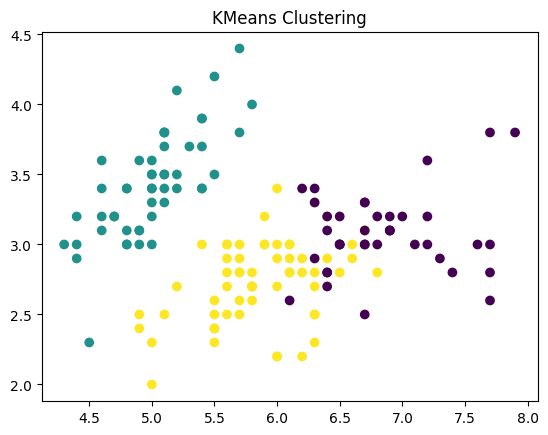

In [69]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels
)

plt.title("KMeans Clustering")
plt.show()

Clustering memungkinkan eksplorasi data tanpa label. K-Means cocok untuk cluster berbentuk bulat, sedangkan DBSCAN unggul dalam mendeteksi outlier dan cluster dengan bentuk tidak beraturan.

# Chapter 11 - Outlier Detection

## Summary

Chapter ini membahas teknik deteksi outlier atau anomali yang bertujuan menemukan data yang berbeda secara signifikan dibandingkan data lainnya.

## Theoretical Explanation

### Outlier

Outlier adalah data yang memiliki karakteristik berbeda dari mayoritas data.

### Isolation Forest

Mendeteksi outlier dengan mengisolasi data menggunakan pohon acak.

### Local Outlier Factor (LOF)

Membandingkan kepadatan lokal suatu data dengan tetangganya.

### One-Class SVM

Melatih model hanya menggunakan data normal untuk mendeteksi anomali.

---

## Code Reproduction

In [70]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data

In [71]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

pred = iso.fit_predict(X)

print(pred[:20])

[ 1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1]


In [72]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    contamination=0.05
)

pred_lof = lof.fit_predict(X)

print(pred_lof[:20])

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1]


In [73]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    nu=0.05
)

pred_svm = ocsvm.fit_predict(X)

print(pred_svm[:20])

[ 1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1]


In [74]:
import numpy as np

print(
    "Isolation Forest Outliers:",
    np.sum(pred == -1)
)

print(
    "LOF Outliers:",
    np.sum(pred_lof == -1)
)

print(
    "One-Class SVM Outliers:",
    np.sum(pred_svm == -1)
)

Isolation Forest Outliers: 8
LOF Outliers: 8
One-Class SVM Outliers: 8


Outlier Detection sangat penting dalam fraud detection, cybersecurity, dan monitoring sistem. Isolation Forest merupakan salah satu metode yang paling populer karena cepat dan efektif.

# Chapter 12 - Cross Validation and Model Evaluation

## Summary

Chapter ini membahas teknik evaluasi model yang digunakan untuk mengukur kemampuan generalisasi model pada data baru.

## Theoretical Explanation

### Cross Validation

Cross Validation membagi dataset menjadi beberapa bagian untuk evaluasi yang lebih stabil.

### K-Fold Cross Validation

Dataset dibagi menjadi K bagian dan setiap bagian digunakan sebagai testing secara bergantian.

### Stratified K-Fold

Memastikan distribusi kelas tetap seimbang pada setiap fold.

### Grid Search

Mencari kombinasi hyperparameter terbaik.

---

## Code Reproduction

In [75]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(
    max_iter=5000
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]


In [77]:
print(
    "Average Score:",
    scores.mean()
)

Average Score: 0.9507995652848935


In [78]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf
)

print(scores)

[0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]


In [79]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=skf
)

print(scores)

[0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]


In [80]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.01,0.1,1,10]
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=5000
    ),
    param_grid,
    cv=5
)

grid.fit(X,y)

print(grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'C': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross Validation memberikan estimasi performa model yang lebih stabil dibandingkan train-test split biasa. Grid Search membantu menemukan kombinasi hyperparameter terbaik secara otomatis.

# Chapter 13 - Deploying scikit-learn Models

## Summary

Chapter ini membahas bagaimana model Machine Learning yang telah dilatih dapat disimpan, dimuat kembali, dan digunakan pada lingkungan produksi.

## Theoretical Explanation

### Model Persistence

Model yang telah dilatih dapat disimpan sehingga tidak perlu dilatih ulang setiap kali digunakan.

### Deployment

Deployment adalah proses mengintegrasikan model ke aplikasi atau sistem produksi.

### Joblib

Library yang umum digunakan untuk menyimpan model Scikit-Learn.

### Production Workflow

Training → Save Model → Load Model → Prediction

---

## Code Reproduction

In [81]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()

X = iris.data
y = iris.target

model = RandomForestClassifier(
    random_state=42
)

model.fit(X,y)

RandomForestClassifier(random_state=42)

In [83]:
import joblib

joblib.dump(
    model,
    "random_forest_model.pkl"
)

print("Model Saved")

Model Saved


In [84]:
loaded_model = joblib.load(
    "random_forest_model.pkl"
)

print("Model Loaded")

Model Loaded


In [85]:
prediction = loaded_model.predict(
    [X[0]]
)

print(prediction)

[0]


In [86]:
print(
    iris.target_names[
        prediction
    ]
)

['setosa']


# Final Conclusion

Melalui reproduksi kode dan pembelajaran teori dari buku *scikit-learn Cookbook*, berbagai konsep penting Machine Learning berhasil dipelajari dan diimplementasikan menggunakan Python dan Scikit-Learn.

Materi yang dipelajari meliputi:

- Scikit-Learn API
- Data Preprocessing
- Dimensionality Reduction
- K-Nearest Neighbors
- Linear Models
- Logistic Regression
- Support Vector Machines
- Tree-Based Models
- Ensemble Learning
- Text Processing
- Clustering
- Outlier Detection
- Model Evaluation
- Model Deployment

Implementasi praktis pada setiap chapter memberikan pemahaman yang lebih mendalam mengenai bagaimana membangun, mengevaluasi, dan menerapkan model Machine Learning pada berbagai jenis permasalahan.

Buku ini menjadi fondasi yang kuat untuk melanjutkan pembelajaran ke bidang yang lebih lanjut seperti Deep Learning, Computer Vision, Natural Language Processing, dan MLOps.

Model deployment merupakan tahap akhir dalam Machine Learning workflow. Dengan menggunakan Joblib, model dapat disimpan dan digunakan kembali tanpa perlu melakukan training ulang.